In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.dummy import DummyClassifier

In [2]:
#create a dataframe from the data and get a general overview of it
df = pd.read_csv("./thyroid_cancer_risk_data.csv")
print(df.info())

# tells us if there are any null values in the columns
for columns in df.columns:
    if df[columns].isnull().sum() > 0:
        print(f"there are null values in {columns}")

# getting an idea of what risk values there are
print(df['Thyroid_Cancer_Risk'].value_counts())
# getting an idea of what diagnoses there are
print(df['Diagnosis'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  object 
 3   Country              212691 non-null  object 
 4   Ethnicity            212691 non-null  object 
 5   Family_History       212691 non-null  object 
 6   Radiation_Exposure   212691 non-null  object 
 7   Iodine_Deficiency    212691 non-null  object 
 8   Smoking              212691 non-null  object 
 9   Obesity              212691 non-null  object 
 10  Diabetes             212691 non-null  object 
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Ri

In [3]:
# create test and training sets with a 40/60 split
train_df, test_df = train_test_split(df, test_size=0.40, random_state=151)

train_df.sort_index()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
5,6,89,Male,UK,African,No,No,No,Yes,Yes,No,4.00,0.98,5.52,0.02,Medium,Benign
7,8,38,Female,India,African,No,No,No,No,No,No,5.54,3.49,9.47,4.30,Medium,Benign
8,9,17,Female,Russia,African,No,Yes,No,No,No,Yes,2.30,2.60,11.89,0.81,High,Malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,212687,58,Female,India,Asian,No,No,No,No,Yes,No,2.00,0.64,11.92,1.48,Low,Benign
212687,212688,89,Male,Japan,Middle Eastern,No,No,No,No,Yes,No,9.77,3.25,7.30,4.46,Medium,Benign
212688,212689,72,Female,Nigeria,Hispanic,No,No,No,No,No,Yes,7.72,2.44,8.71,2.36,Medium,Benign
212689,212690,85,Female,Brazil,Middle Eastern,No,No,No,No,No,Yes,5.62,2.53,9.62,1.54,Medium,Benign


In [4]:
#little summary of the training data
summary = train_df.describe(include='all')
summary

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
count,127614.000000,127614.000000,127614,127614,127614,127614,127614,127614,127614,127614,127614,127614.000000,127614.000000,127614.000000,127614.000000,127614,127614
unique,NaN,NaN,2,10,5,2,2,2,2,2,2,NaN,NaN,NaN,NaN,3,2
top,NaN,NaN,Female,India,Caucasian,No,No,No,No,No,No,NaN,NaN,NaN,NaN,Low,Benign
freq,NaN,NaN,76628,25444,38388,89323,108476,95736,102132,89288,101908,NaN,NaN,NaN,NaN,65305,98055
mean,106438.820357,51.913528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.039361,2.002338,8.246700,2.504147,NaN,NaN
std,61394.754499,21.625877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.861761,0.866227,2.164917,1.445192,NaN,NaN
min,2.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.500000,4.500000,0.000000,NaN,NaN
25%,53364.500000,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.560000,1.250000,6.370000,1.250000,NaN,NaN
50%,106376.500000,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.030000,2.010000,8.240000,2.510000,NaN,NaN
75%,159618.750000,71.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.520000,2.750000,10.120000,3.760000,NaN,NaN


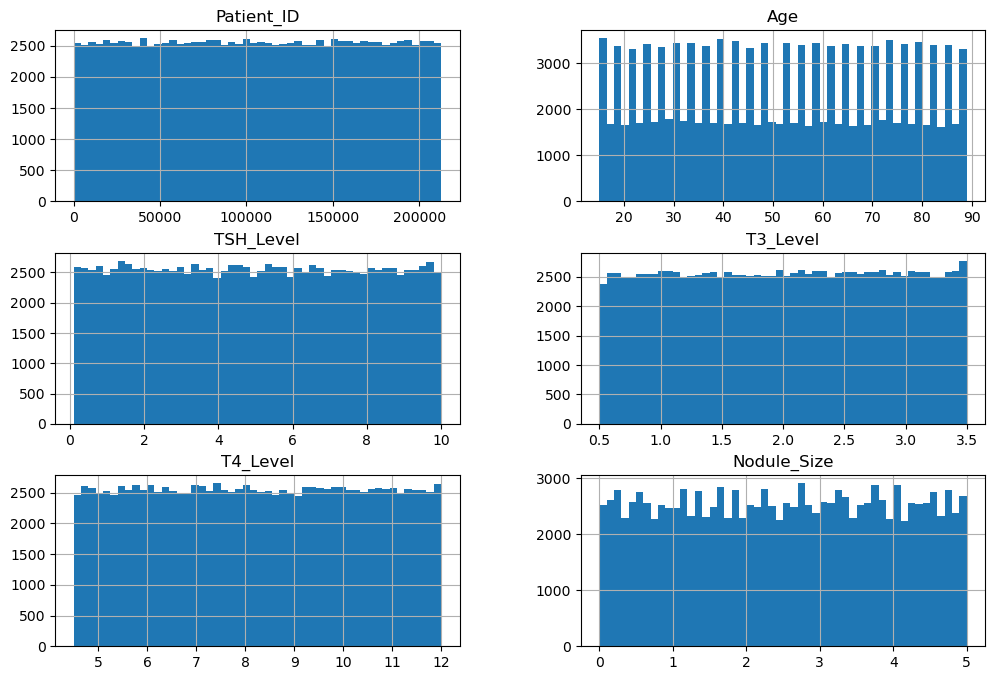

In [5]:
#histogram of the numeric data 
train_df.hist(bins=50, figsize=(12, 8))
plt.show()

In [6]:
# if a feature only has two possible values it gets
# added to the binary features array
binary_features = []
for columns in df.columns:
    if len(df[columns].unique()) < 3:
        binary_features.append(columns)
print(binary_features)

['Gender', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Diagnosis']


In [7]:
#seperate the rest of the features based on the type of value present within
numeric_features = df[['Age','TSH_Level','T3_Level','T4_Level','Nodule_Size']].columns.tolist()
categorical_features = df[['Country','Ethnicity']].columns.tolist()


In [8]:
#create a basic transformation for the two types of features present
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

binary_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')


In [9]:
#drop the target variable from training data and make it the only variable of the test data
X_train = train_df.drop(columns=['Thyroid_Cancer_Risk'])
y_train = train_df['Thyroid_Cancer_Risk']

x_test = test_df.drop(columns=['Thyroid_Cancer_Risk'])
y_test = test_df['Thyroid_Cancer_Risk']


In [10]:
#create a preprocessor using column transformer
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),   
    (categorical_transformer, categorical_features),
    (binary_transformer, binary_features)
    
)
preprocessor

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['Age', 'TSH_Level', 'T3_Level', 'T4_Level',
                                  'Nodule_Size']),
                                ('onehotencoder-1',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Country', 'Ethnicity']),
                                ('onehotencoder-2',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore'),
                                 ['Gender', 'Family_History',
                                  'Radiation_Exposure', 'Iodine_Deficiency',
                                  'Smoking', 'Obesity', 'Diabetes',
                                  'Diagnosis'])])

In [23]:
# create a dummy classifier 
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(x_test)

In [11]:
# create a random forest classifier and then a pipeline with the
# preprocessor and classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=151)

piper = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])


In [12]:
#fit the pipeline and use it to predict x test
piper.fit(X_train,y_train)

y_pred = piper.predict(x_test)

In [13]:
# get the accuracy of the predicted values
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.6394090059593075


In [ ]:
# get the recall and precision scores

print(recall_score(y_test, y_pred, average='weighted'))
print(precision_score(y_test, y_pred, average='weighted'))

0.6394090059593075
0.5931693884016966


In [ ]:
# do a grid search for optimizing the hyperparameters
param_grid = {
    'classifier__max_depth': [3,5,7,10],
    'classifier__n_estimators': [50, 100, 200, 400],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(piper, param_grid=param_grid, cv=5, scoring='accuracy', verbose=3)
grid_search.fit(X_train, y_train)
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__n_estimators=50;, score=0.594 total time=   3.0s
[CV 2/5] END classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__n_estimators=50;, score=0.593 total time=   3.1s
[CV 3/5] END classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__n_estimators=50;, score=0.594 total time=   3.0s
[CV 4/5] END classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__n_estimators=50;, score=0.593 total time=   3.0s
[CV 5/5] END classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__n_estimators=50;, score=0.591 total time=   3.4s
[CV 1/5] END classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__n_estimators=100;, score=0.594 total time=   4.7s
[CV 2/5] END classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__n_estimators=100;, score=0.593 total time=   5.5s
[CV 3/5] END classi

In [ ]:
#use the optimal hyperparameters to make a final classifier
# and see its test and train scores
final_tree = make_pipeline(preprocessor, RandomForestClassifier(max_depth=10, min_samples_leaf=1, n_estimators=100))
final_tree.fit(X_train,y_train)
test_score = final_tree.score(x_test,y_test)
train_score= final_tree.score(X_train,y_train)
print(test_score)
print(train_score)

0.6581214664362871
0.6607974046734685


In [ ]:
#now we check the f1 score of the final model

y_pred = final_tree.predict(x_test)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f1_weighted)

0.5303314603076039


In [ ]:
# now lets compare those scores to 
# those generated from the dummy classifier
dummy_test_score = dummy.score(x_test,y_test)
dummy_train_score = dummy.score(X_train,y_train)
dummy_f1 = f1_score(y_test, dummy_pred, average='weighted')
print(dummy_test_score)
print(dummy_train_score)
print(dummy_f1)

0.5064000846292183
0.5117385239863965
0.34046870858427913


From these results we can see that, although my model has a higher accuracy than the baseline, in a matter of life or death like cancer prediction, it's nowhere near high enough to see serious usage.